In [53]:
import pandas as pd
df = pd.read_csv(r'C:\Users\ASUS\OneDrive\Pictures\Desktop\Innomatics_workspace\Machine_Learning\Datasets\Titanic-Dataset.csv')

In [54]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [55]:
df.columns = [col.lower() for col in df.columns]

In [56]:
df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='str')

In [57]:
df = df.drop(columns = ['passengerid' ,'ticket' , 'name'])

## Univariate Analysis

numerical

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   cabin     204 non-null    str    
 8   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 68.7 KB


In [59]:
df['age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [60]:
df['age'].isna().sum()

np.int64(177)

In [61]:
df["deck"] = df["cabin"].str[0]

df = df.drop(columns=["cabin"])

In [62]:
num_col = df.select_dtypes(include = ['int64','float64']).columns
cat_col = df.select_dtypes(include = ['object']).columns

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11020\3742821334.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include = ['object']).columns


In [63]:
num_col

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')

In [64]:
cat_col

Index(['sex', 'embarked', 'deck'], dtype='str')

In [65]:
df[num_col].isna().sum()

survived      0
pclass        0
age         177
sibsp         0
parch         0
fare          0
dtype: int64

In [66]:
df[num_col].describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [67]:
import matplotlib.pyplot as plt
import seaborn as sns


<Axes: xlabel='age', ylabel='Count'>

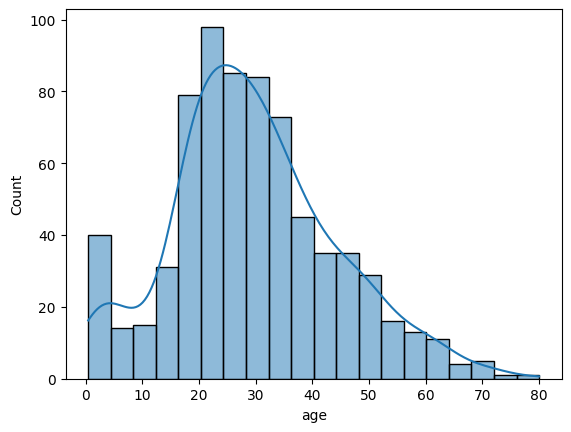

In [68]:
sns.histplot(df['age'],kde = True)

it is slightly right skewed then normally filled it by 'median'

In [69]:
df[num_col].isna().sum()

survived      0
pclass        0
age         177
sibsp         0
parch         0
fare          0
dtype: int64

In [70]:
df[num_col].duplicated().sum()

np.int64(134)

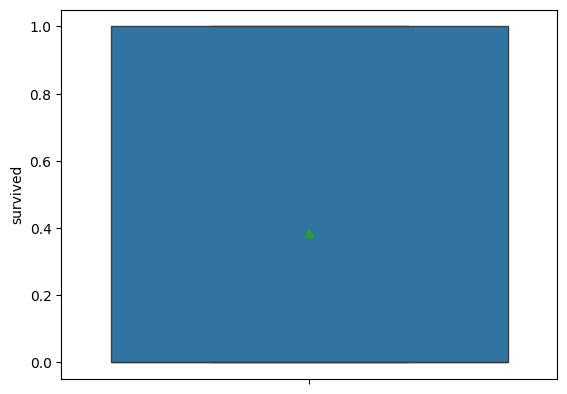

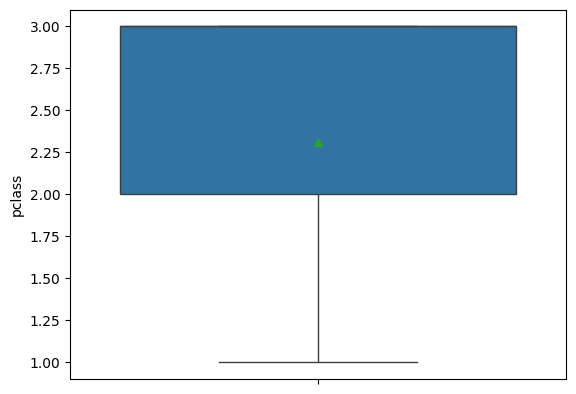

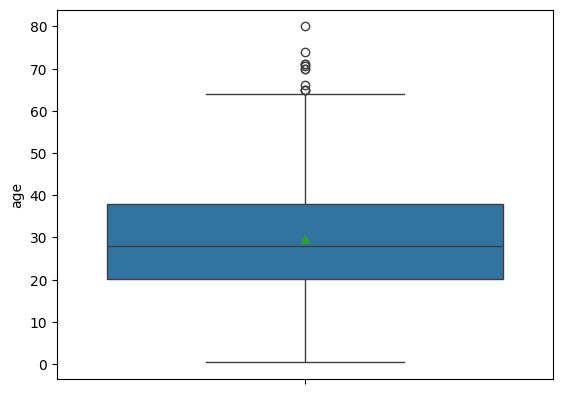

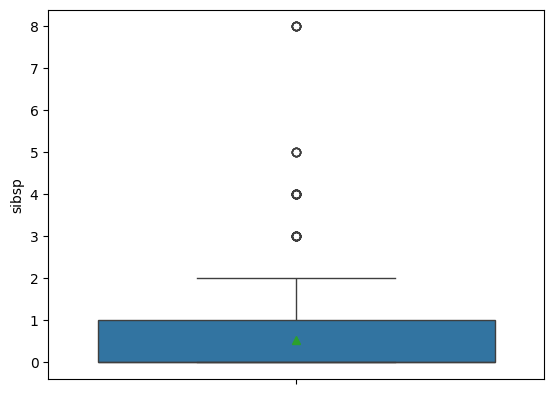

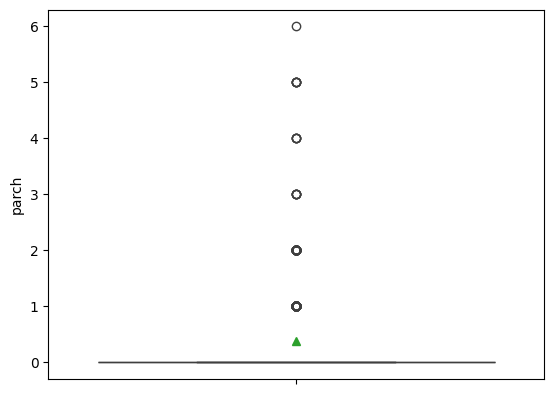

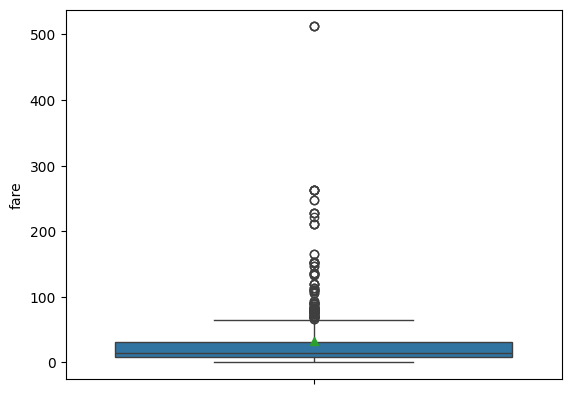

In [71]:
for i in num_col:
    sns.boxplot(df[i] , showmeans = True)
    plt.show()

In [72]:
df['sibsp'].unique()

array([1, 0, 3, 4, 2, 5, 8])

In [73]:
df['parch'].unique()

array([0, 1, 2, 5, 3, 4, 6])

In [74]:
df[num_col]

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000
887,1,1,19.0,0,0,30.0000
888,0,3,NaN,1,2,23.4500
889,1,1,26.0,0,0,30.0000


Categorical Col

In [75]:
for i in cat_col:
    print(f"Column: {i}")
    print("Unique Values:")
    print(df[i].unique())
    print("\nNumber of Unique Values:")
    print(df[i].nunique())
    print("-" * 50)

Column: sex
Unique Values:
<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

Number of Unique Values:
2
--------------------------------------------------
Column: embarked
Unique Values:
<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

Number of Unique Values:
3
--------------------------------------------------
Column: deck
Unique Values:
<ArrowStringArray>
[nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str

Number of Unique Values:
8
--------------------------------------------------


In [76]:
df[cat_col].isna().sum()

sex           0
embarked      2
deck        687
dtype: int64

In [77]:
df['embarked'].unique()

<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [78]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'deck'],
      dtype='str')

### Bivariate Analysis

num x num

<Axes: >

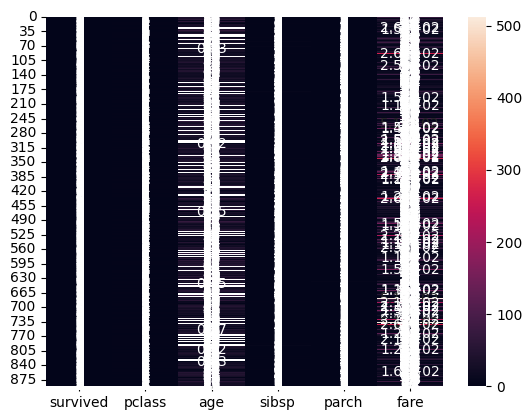

In [79]:
sns.heatmap(data = df[num_col] , annot = True)

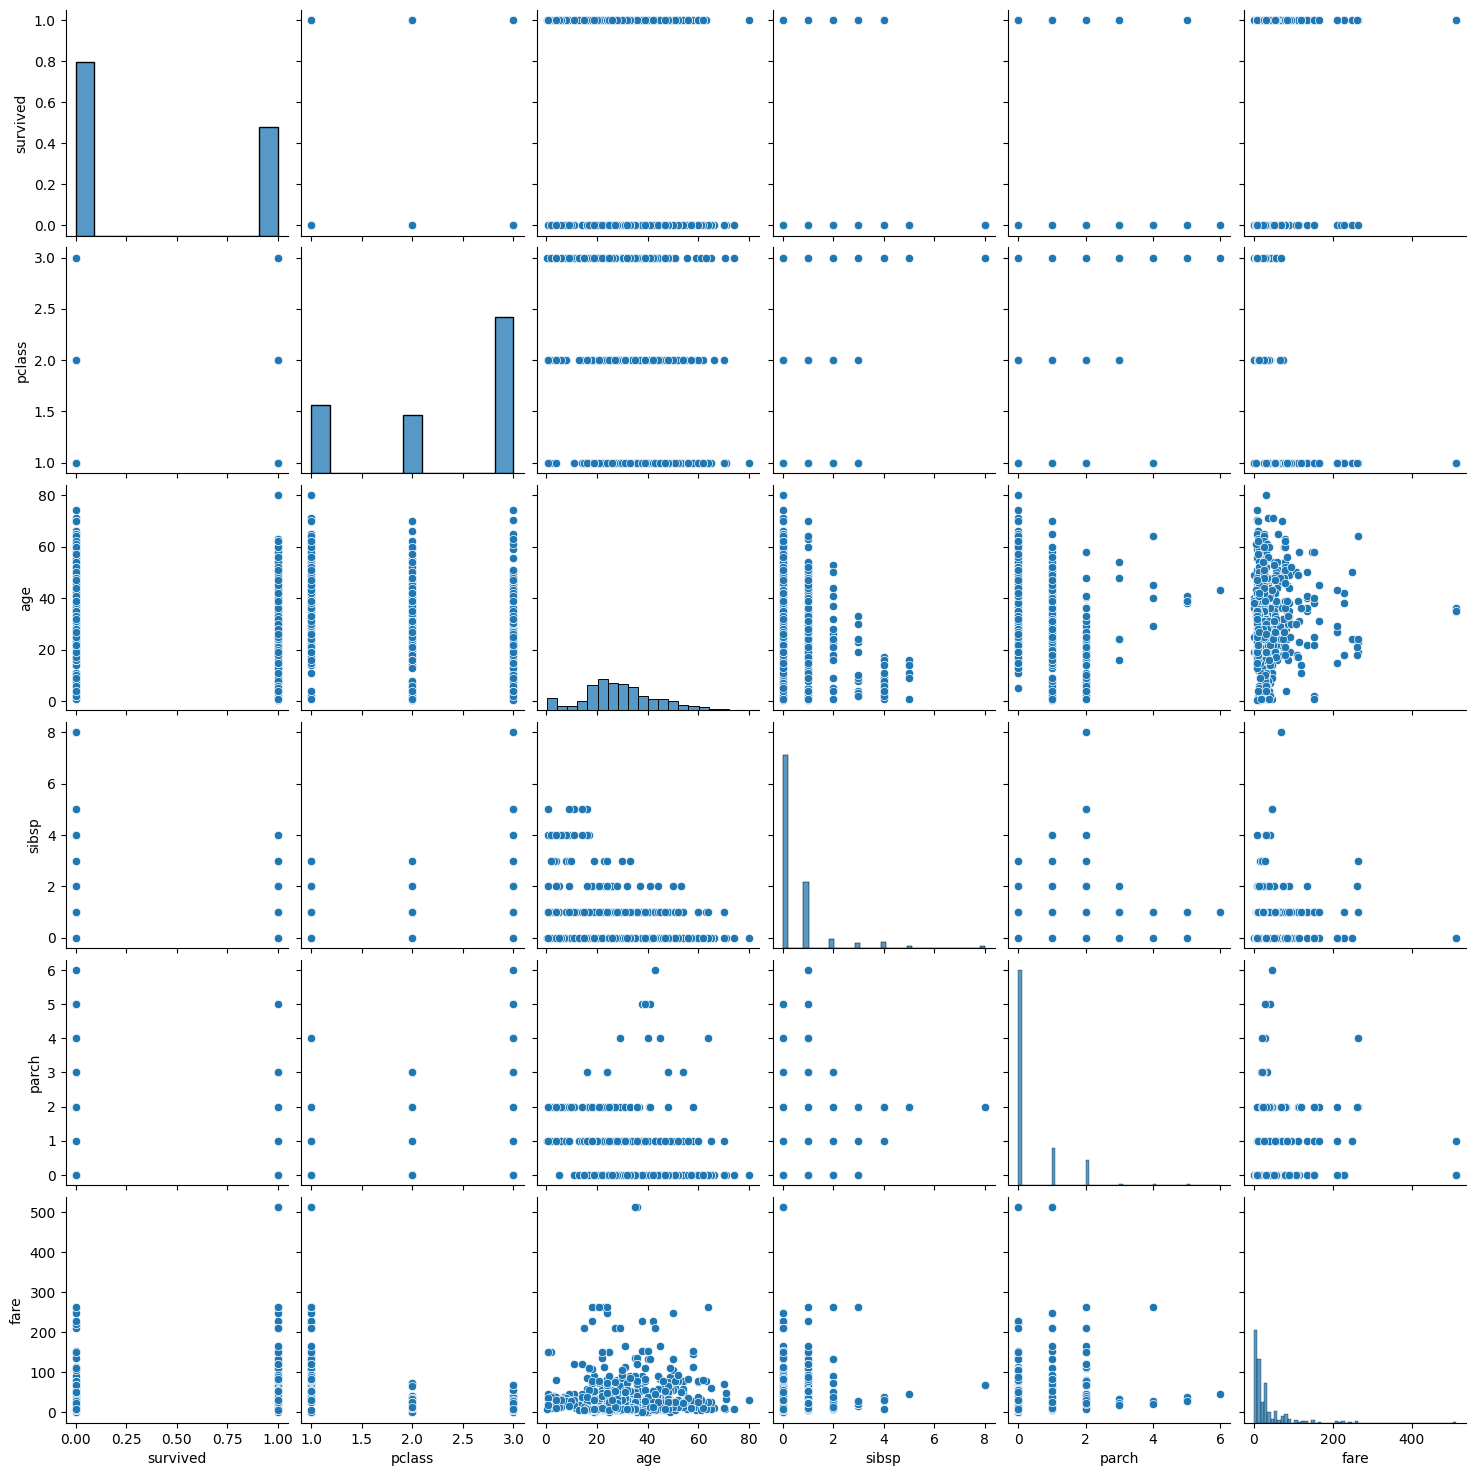

In [80]:
sns.pairplot(df[num_col]) # Alternative of heatmap (num x num)
plt.show()

cat x cat

In [81]:
# for i in range(len(cat_col)):
#     for j in range(i + 1, len(cat_col)):

#         ct = pd.crosstab(
#             df[cat_col[i]],
#             df[cat_col[j]],
#             normalize='index'
#         )

#         plt.figure(figsize=(8, 5))
#         sns.heatmap(
#             ct,
#             annot=True,
#             fmt='.2%',
#             cmap='Blues'
#         )

#         plt.title(f'{cat_col[i]} vs {cat_col[j]}')
#         plt.xlabel(cat_col[j])
#         plt.ylabel(cat_col[i])
#         plt.show()

In [82]:
# from statsmodels.graphics.mosaicplot import mosaic

# mosaic(df, ['sex', 'survived'])

# plt.show()

sex vs every categorical column

In [83]:
cat_col

Index(['sex', 'embarked', 'deck'], dtype='str')

In [84]:
# for i in range(len(cat_col)):

#     ct = pd.crosstab(
#         df['survived'],
#         df[cat_col[i]],
#         normalize='index'
#     )

#     ct.plot(
#         kind='bar',
#         stacked=True,
#         figsize=(8, 5)
#     )

#     plt.title(f'survived vs {cat_col[i]}')
#     plt.ylabel('Proportion')
#     plt.xlabel('survived')
#     plt.show()

In [85]:
# for i in range(len(cat_col)):

#     ct = pd.crosstab(
#         df['sex'],
#         df[cat_col[i]],
#         normalize='index'
#     )

#     ct.plot(
#         kind='bar',
#         stacked=True,
#         figsize=(8, 5)
#     )

#     plt.title(f'Sex vs {cat_col[i]}')
#     plt.ylabel('Proportion')
#     plt.xlabel('sex')
#     plt.show()

In [86]:
# for i in range(len(cat_col)):

#     ct = pd.crosstab(
#         df['embarked'],
#         df[cat_col[i]],
#         normalize='index'
#     )

#     ct.plot(
#         kind='bar',
#         stacked=True,
#         figsize=(8, 5)
#     )

#     plt.title(f'Embarked vs {cat_col[i]}')
#     plt.ylabel('Proportion')
#     plt.xlabel('Embarked')
#     plt.show()

In [87]:
cat_col

Index(['sex', 'embarked', 'deck'], dtype='str')

In [88]:
# for i in range(len(cat_col)):

#     ct = pd.crosstab(
#         df['cabin'],
#         df[cat_col[i]],
#         normalize='index'
#     )

#     ct.plot(
#         kind='bar',
#         stacked=True,
#         figsize=(8, 5)
#     )

#     plt.title(f'cabin vs {cat_col[i]}')
#     plt.ylabel('Proportion')
#     plt.xlabel('cabin')
#     plt.show()

cat x num

In [89]:
num_col

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')

In [90]:
cat_col

Index(['sex', 'embarked', 'deck'], dtype='str')

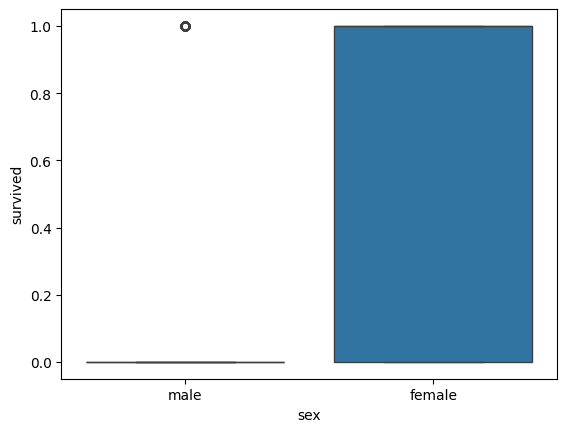

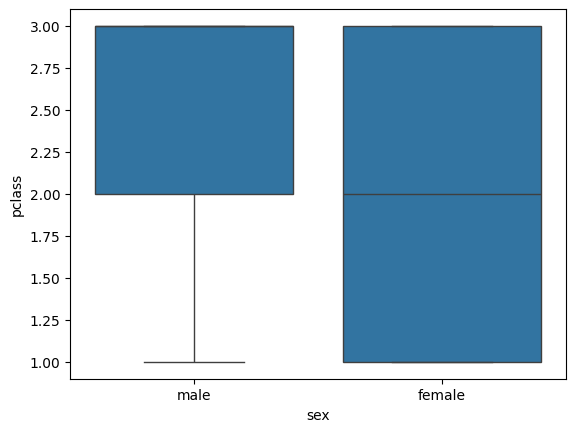

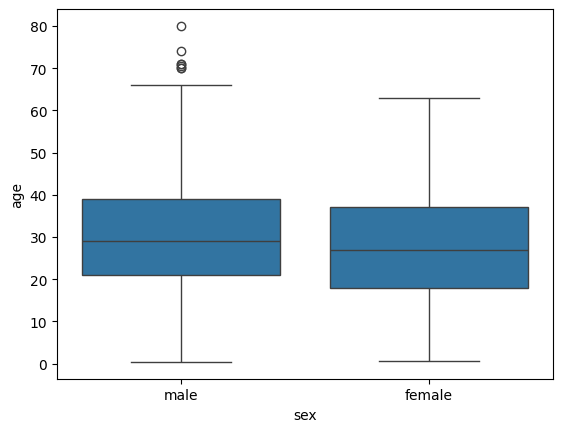

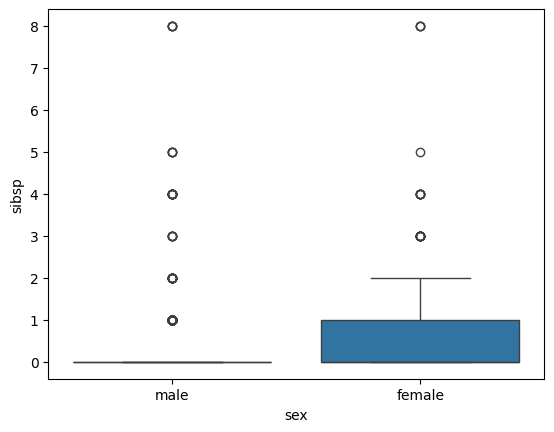

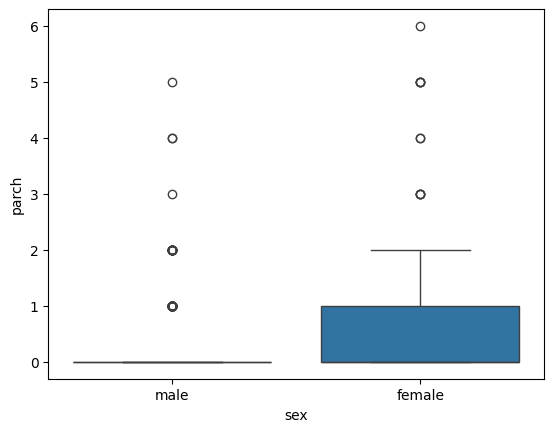

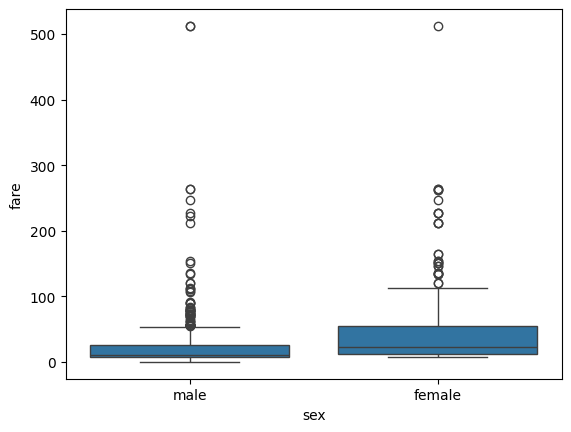

In [91]:
for i in num_col:
  sns.boxplot(
      data=df,
      x='sex',
      y=i
  )

  plt.show()

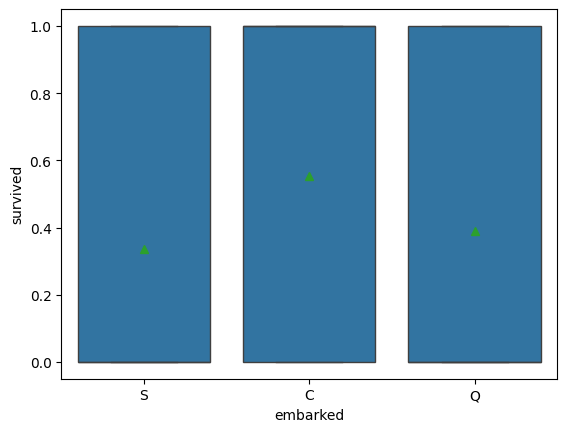

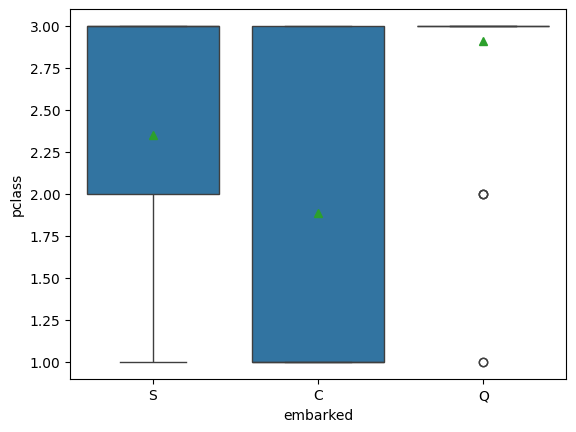

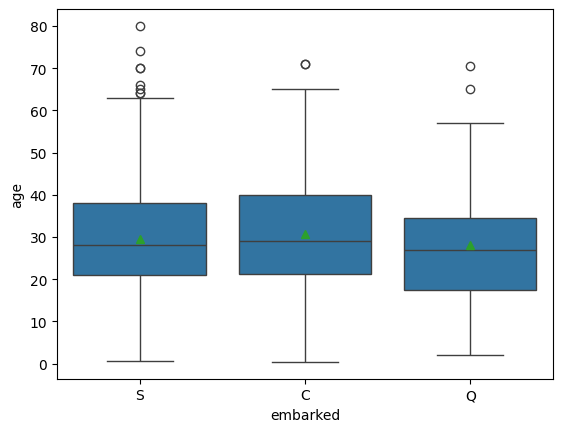

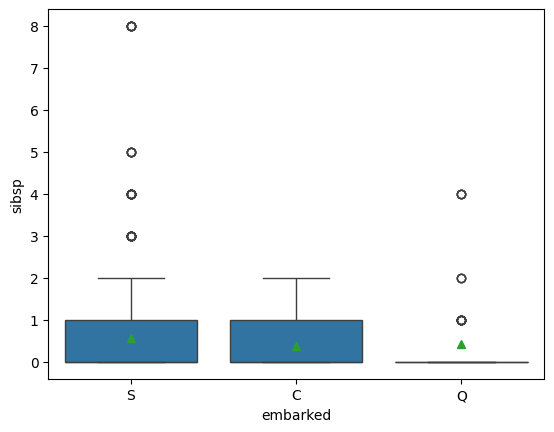

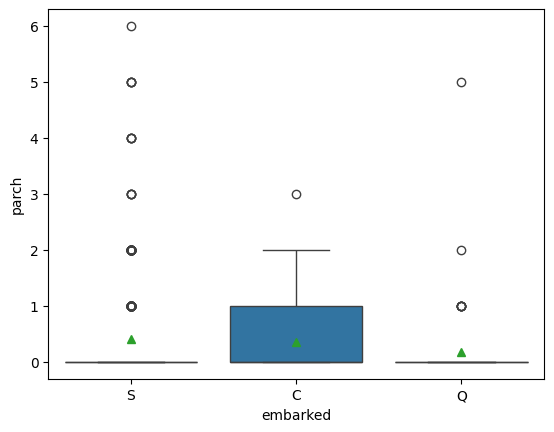

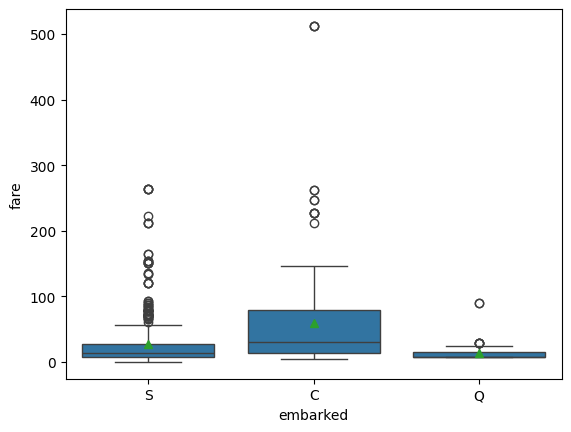

In [92]:
for i in num_col:
  sns.boxplot(data = df , x = 'embarked' , y = i , showmeans  = True)
  plt.show()

In [93]:
num_col

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')

In [94]:
cat_col

Index(['sex', 'embarked', 'deck'], dtype='str')

In [95]:
df.groupby('sex')[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

survived                                    pclass                   \
          count      mean median       std min max  count      mean median   
sex                                                                          
female      314  0.742038    1.0  0.438211   0   1    314  2.159236    2.0   
male        577  0.188908    0.0  0.391775   0   1    577  2.389948    3.0   

                 ...  parch                    fare                    \
            std  ... median       std min max count       mean median   
sex              ...                                                    
female  0.85729  ...    0.0  1.022846   0   6   314  44.479818   23.0   
male    0.81358  ...    0.0  0.612294   0   5   577  25.523893   10.5   

                                   
              std   min       max  
sex                                
female  57.997698  6.75  512.3292  
male    43.138263  0.00  512.3292  

[2 rows x 36 columns]

In [96]:
df.groupby('embarked')[['survived', 'pclass', 'parch', 'fare']].agg(
    [
        'count' , 'mean' , 'std' , 'min' , 'max'
    ])

survived                             pclass                          \
            count      mean       std min max  count      mean       std min   
embarked                                                                       
C             168  0.553571  0.498608   0   1    168  1.886905  0.944100   1   
Q              77  0.389610  0.490860   0   1     77  2.909091  0.369274   1   
S             644  0.336957  0.473037   0   1    644  2.350932  0.789402   1   

             parch                              fare                        \
         max count      mean       std min max count       mean        std   
embarked                                                                     
C          3   168  0.363095  0.660481   0   3   168  59.954144  83.912994   
Q          3    77  0.168831  0.656999   0   5    77  13.276030  14.188047   
S          3   644  0.413043  0.853253   0   6   644  27.079812  35.887993   

                            
             min       max  
embarked                    
C         4.0125  512.3292  
Q         6.7500   90.0000  
S         0.0000  263.0000

In [97]:
df.groupby('embarked')[[ 'age', 'sibsp']].agg(
    ['count' , 'mean' ,'std' , 'min' , 'max']
)

age                                   sibsp                      \
         count       mean        std   min   max count      mean       std   
embarked                                                                     
C          130  30.814769  15.434860  0.42  71.0   168  0.386905  0.557213   
Q           28  28.089286  16.915396  2.00  70.5    77  0.428571  0.979105   
S          554  29.445397  14.143192  0.67  80.0   644  0.571429  1.216600   

                  
         min max  
embarked          
C          0   2  
Q          0   4  
S          0   8

ALL Cat × Num combinations

In [98]:
# for cat in cat_col:
#     for num in num_col:

#         plt.figure(figsize=(8, 5))

#         sns.boxplot(
#             data=df,
#             x=cat,
#             y=num
#         )

#         plt.title(f'{cat} vs {num}')
#         plt.show()

### Multivariate Analysis

1. Correlation heatmap
2. Pairplot / important numerical feature combinations
3. Categorical × categorical × target
4. Numerical × categorical × target
5. Feature interactions
6. GroupBy / pivot analysis
7. Multicollinearity
8. Missing-value patterns
9. Multivariate outliers when relevant
10. PCA/other dimensionality reduction only when useful

Numerical × Numerical × Target

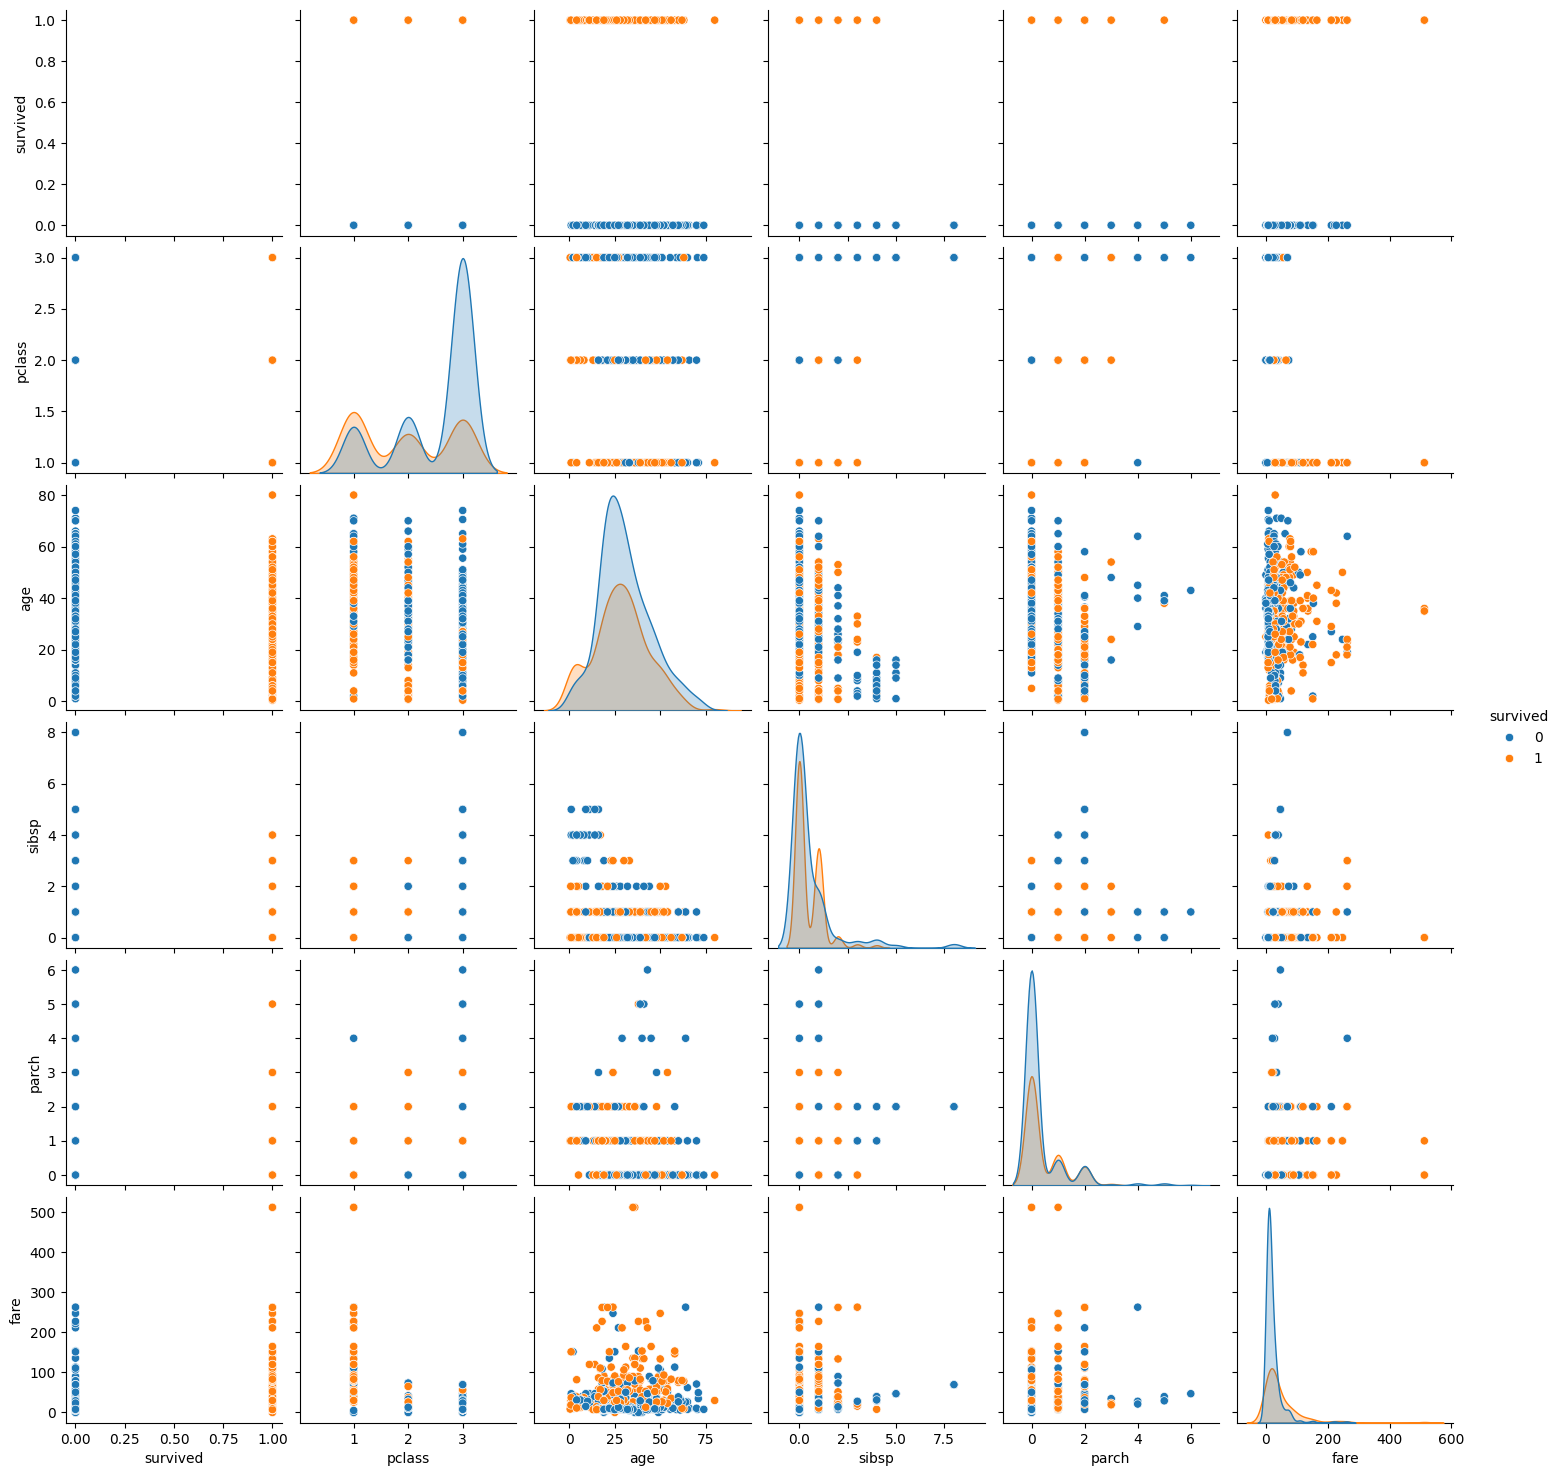

In [99]:
#sns.pairplot(df, vars=num_col, hue='target')
sns.pairplot(df , vars = num_col , hue = 'survived')

multicollinearity means two or more numerical input features are highly related to each other.

In [100]:
num_features = df[num_col].select_dtypes(include = ['number'])
corr = num_features.corr()


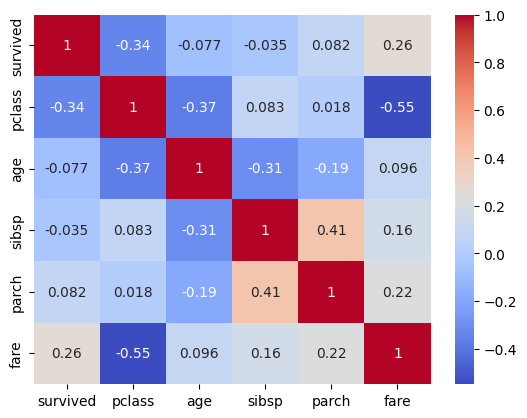

In [101]:
sns.heatmap(corr , annot = True , cmap = 'coolwarm')
plt.show()

Using VIF for correlation

In [102]:
#%pip install statsmodels

In [ ]:
# to detect multicollinearity among numerical features.
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[num_col].dropna()

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Feature,VIF
0,survived,1.241856
1,pclass,1.920486
2,age,1.372183
3,sibsp,1.287942
4,parch,1.238222
5,fare,1.586495


VIF is not used to check correlation with the target.

Feature ↔ Feature

**But don't blindly remove the highest VIF**
```
Before removing a feature, consider:

VIF → Is it highly multicollinear?
Domain importance → Is the feature important for your problem?
Relationship with target → Does it provide useful information?
Duplicate/redundant information → Is another feature representing almost the same thing?
Model performance → Does removing it improve or hurt validation performance?

Categorical × Categorical × Target

In [104]:
num_col

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')

In [105]:
cat_col

Index(['sex', 'embarked', 'deck'], dtype='str')

In [106]:
pd.crosstab(
    [df['sex'], df['embarked']],
    df['survived'],
    normalize='index'
)*100

survived                 0          1
sex    embarked                      
female C         12.328767  87.671233
       Q         25.000000  75.000000
       S         31.034483  68.965517
male   C         69.473684  30.526316
       Q         92.682927   7.317073
       S         82.539683  17.460317

Numerical × Categorical × Target ⭐

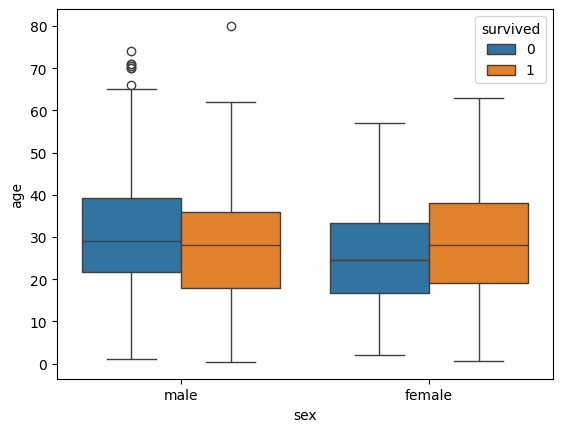

In [107]:
# sns.boxplot(
#     x='sex',
#     y='age',
#     hue='target',
#     data=df
# )

sns.boxplot(data = df , x = 'sex' , y = 'age' , hue = 'survived')
plt.show()

Target Distribution with Multiple Features

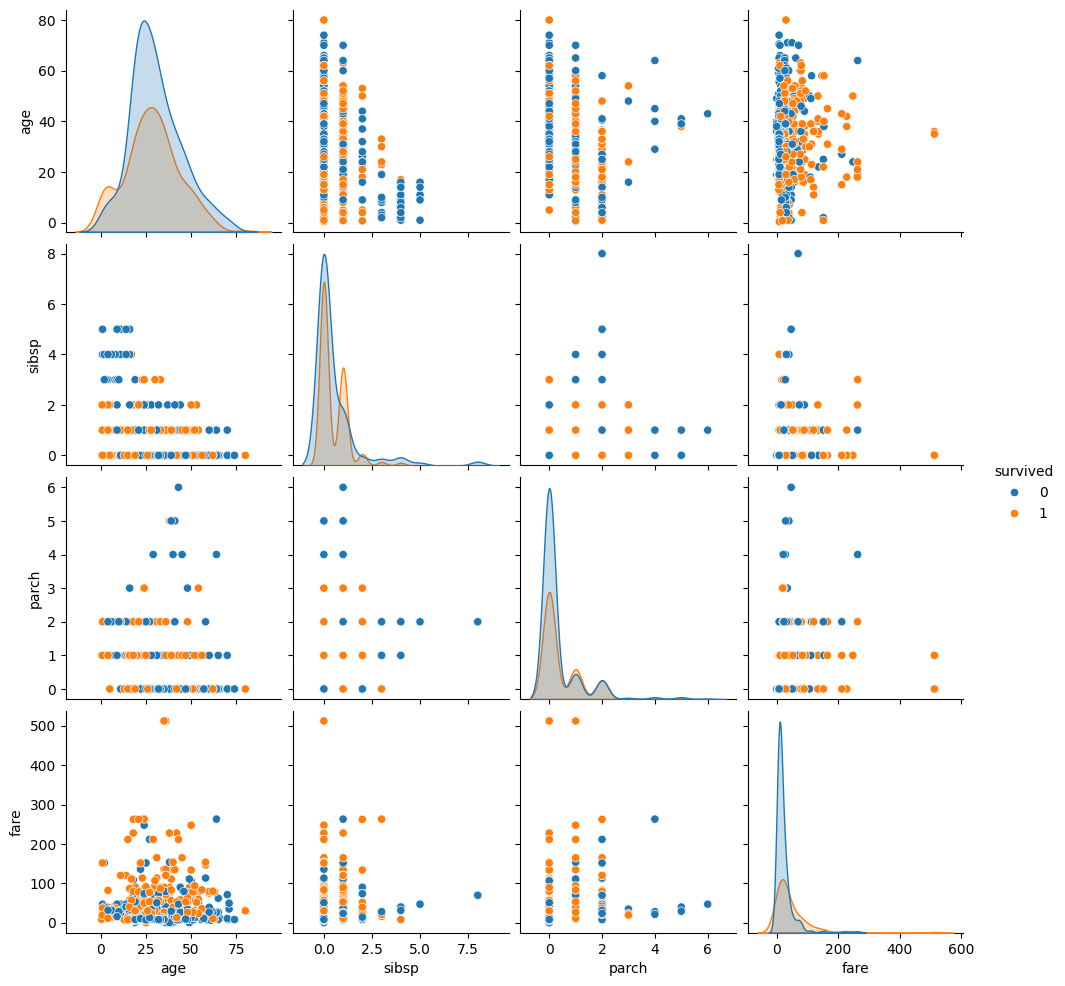

In [108]:
# sns.pairplot(
#     df,
#     vars=['age', 'income', 'balance'],
#     hue='target'
# )

sns.pairplot(df , vars = ['age', 'sibsp', 'parch', 'fare' ] , hue = 'survived')


In [109]:
cat_col

Index(['sex', 'embarked', 'deck'], dtype='str')

Remove Duplicate Columns

In [110]:
duplicate_cols = df.columns[df.T.duplicated()]
print(duplicate_cols)

Index([], dtype='str')


In [111]:
df = df.T.drop_duplicates().T

**Best real-world ML structure**

```
Train/Test Split
       ↓
Pipeline
       ↓
Imputation
       ↓
Encoding
       ↓
Scaling
       ↓
Feature Selection
       ↓
Model

Split of Data

In [112]:
X = df.drop(columns = ['survived'])
y = df['survived']

In [113]:
from sklearn.model_selection import train_test_split

In [114]:
x_train , x_test , y_train, y_test = train_test_split(X ,y , test_size = 0.2 , stratify = y , random_state = 42)

In [115]:
print("x_train:", type(x_train), x_train.shape)
print("x_test :", type(x_test), x_test.shape)
print("y_train:", type(y_train), y_train.shape)
print("y_test :", type(y_test), y_test.shape)

x_train: <class 'pandas.DataFrame'> (712, 8)
x_test : <class 'pandas.DataFrame'> (179, 8)
y_train: <class 'pandas.Series'> (712,)
y_test : <class 'pandas.Series'> (179,)


##PIPELINE

In [116]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , OneHotEncoder , OrdinalEncoder

In [117]:
num_pipe = Pipeline([
    ('impute' , SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('impute' , SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore' , sparse_output = False))
])

In [118]:
num_col[1:]

Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')

In [119]:
cat_col

Index(['sex', 'embarked', 'deck'], dtype='str')

In [120]:
preprocess = ColumnTransformer([
    ('num' , num_pipe , num_col[1:]),
    ('cat', cat_pipe , cat_col)
])

In [121]:
print(type(x_train))
print(x_train.shape)

print(type(x_test))
print(x_test.shape)

<class 'pandas.DataFrame'>
(712, 8)
<class 'pandas.DataFrame'>
(179, 8)


In [122]:
x_train = preprocess.fit_transform(x_train)
x_test = preprocess.transform(x_test)

In [123]:
print(type(x_train))
print(x_train.shape)

print(type(x_test))
print(x_test.shape)

<class 'numpy.ndarray'>
(712, 18)
<class 'numpy.ndarray'>
(179, 18)


###Feature Selection
Priority :-

Filter --> Wrapper --> Embedded

```
Feature Selection
      │
      ├── 1. Filter
      │      ├── Correlation
      │      ├── Chi-Square
      │      ├── ANOVA
      │      ├── Mutual Information
      │      └── Variance Threshold
      │
      ├── 2. Wrapper
      │      ├── RFE
      │      ├── RFECV
      │      └── Sequential Selection
      │
      └── 3. Embedded
             ├── Lasso / L1
             ├── Elastic Net
             ├── Decision Tree
             └── Random Forest


####Filter-based


2. Remove Low Variance Threshold

In [124]:
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold = 0.001)

In [125]:
sel.fit(x_train)

,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.001


In [126]:
sum(sel.get_support())

np.int64(18)

In [127]:
x_train

array([[ 0.82956755, -0.08113533, -0.46508428, ...,  0.        ,
         0.        ,  0.        ],
       [-0.37094484, -0.08113533, -0.46508428, ...,  0.        ,
         0.        ,  0.        ],
       [-1.57145722, -0.08113533, -0.46508428, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.82956755,  1.41700669,  0.47833454, ...,  0.        ,
         0.        ,  0.        ],
       [-1.57145722,  1.34017889, -0.46508428, ...,  0.        ,
         0.        ,  0.        ],
       [-1.57145722, -0.08113533, -0.46508428, ...,  0.        ,
         0.        ,  0.        ]], shape=(712, 18))

In [128]:
features = preprocess.get_feature_names_out()
len(features)

18

In [129]:
features

array(['num__pclass', 'num__age', 'num__sibsp', 'num__parch', 'num__fare',
       'cat__sex_female', 'cat__sex_male', 'cat__embarked_C',
       'cat__embarked_Q', 'cat__embarked_S', 'cat__deck_A', 'cat__deck_B',
       'cat__deck_C', 'cat__deck_D', 'cat__deck_E', 'cat__deck_F',
       'cat__deck_G', 'cat__deck_T'], dtype=object)

In [130]:
columns = features[sel.get_support()]
columns

array(['num__pclass', 'num__age', 'num__sibsp', 'num__parch', 'num__fare',
       'cat__sex_female', 'cat__sex_male', 'cat__embarked_C',
       'cat__embarked_Q', 'cat__embarked_S', 'cat__deck_A', 'cat__deck_B',
       'cat__deck_C', 'cat__deck_D', 'cat__deck_E', 'cat__deck_F',
       'cat__deck_G', 'cat__deck_T'], dtype=object)

In [131]:

removed = features[~sel.get_support()]

print("Selected:", columns)
print("Removed:", removed)

Selected: ['num__pclass' 'num__age' 'num__sibsp' 'num__parch' 'num__fare'
 'cat__sex_female' 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q'
 'cat__embarked_S' 'cat__deck_A' 'cat__deck_B' 'cat__deck_C' 'cat__deck_D'
 'cat__deck_E' 'cat__deck_F' 'cat__deck_G' 'cat__deck_T']
Removed: []


In [132]:
x_train = sel.transform(x_train)
x_test = sel.transform(x_test)

x_train = pd.DataFrame(x_train , columns = columns)
x_test = pd.DataFrame(x_test , columns = columns)

In [133]:
x_train.shape
x_test.shape

(179, 18)

### correlation

In [134]:
import seaborn as sns


<Axes: >

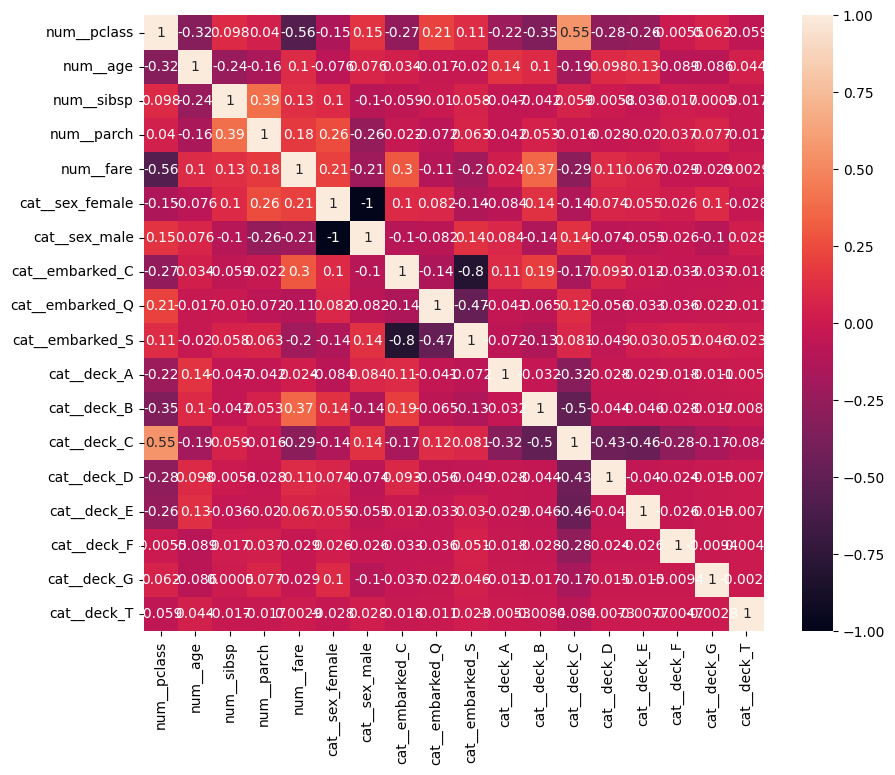

In [135]:
plt.figure(figsize = (10,8))
sns.heatmap(x_train.corr() , annot = True)

In [136]:
corr = pd.concat([x_train, y_train], axis=1).corr()["survived"].sort_values()

print(corr)

cat__sex_male     -0.079456
cat__deck_F       -0.071295
num__sibsp        -0.060291
num__pclass       -0.058357
cat__deck_D       -0.046294
cat__embarked_S   -0.045939
cat__deck_E       -0.039981
cat__deck_T       -0.033160
cat__deck_A       -0.015642
num__age          -0.014289
cat__embarked_Q    0.011275
cat__deck_G        0.013974
num__parch         0.021399
cat__deck_B        0.041643
cat__embarked_C    0.043932
cat__deck_C        0.054136
num__fare          0.077805
cat__sex_female    0.079456
survived           1.000000
Name: survived, dtype: float64


In [137]:
type(x_train)

pandas.DataFrame

In [139]:
corr_matrix = x_train.corr()
columns = corr_matrix.columns

Loops to verify the higher correlations

In [142]:
cols_to_drop = []
for i in range(len(columns)):
    for j in range(i+1 , len(columns)):
        if corr_matrix.loc[columns[i] , columns[j]] > 0.95:
            cols_to_drop.append(columns[j])
        
print(cols_to_drop)

[]
